### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

/home/pmarrec/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


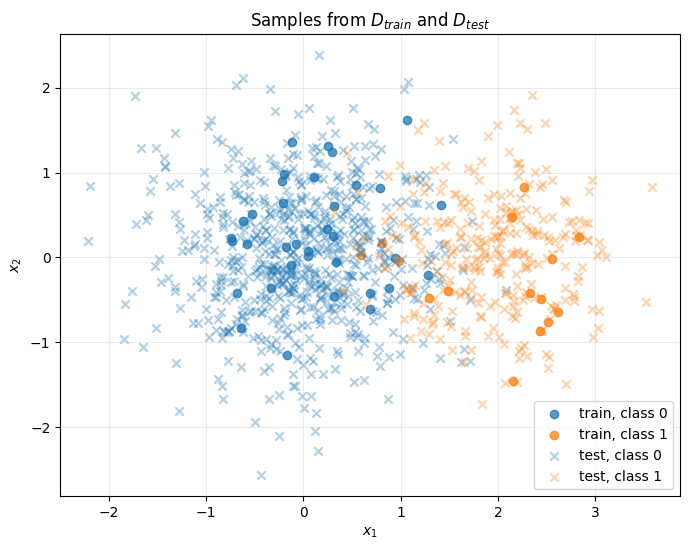

Train class counts: [35 15]
Test class counts:  [705 295]


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 20260427
rng = np.random.default_rng(RANDOM_SEED)

MU_0 = np.array([0.0, 0.0])
SIGMA_0 = np.array([[0.5, 0.0], [0.0, 0.5]])
SIGMA_1 = np.array([[0.4, 0.0], [0.0, 0.4]])


def simulate_data(n, epsilon=2.0, p=0.3, rng=None):
    """Generate D(n | epsilon, p)."""
    if rng is None:
        rng = np.random.default_rng()

    y = (rng.random(n) < p).astype(int)
    x = np.empty((n, 2))

    mask_0 = y == 0
    mask_1 = ~mask_0
    x[mask_0] = rng.multivariate_normal(MU_0, SIGMA_0, size=mask_0.sum())
    x[mask_1] = rng.multivariate_normal(np.array([epsilon, 0.0]), SIGMA_1, size=mask_1.sum())
    return x, y


X_train, y_train = simulate_data(50, epsilon=2.0, p=0.3, rng=rng)
X_test, y_test = simulate_data(1_000, epsilon=2.0, p=0.3, rng=rng)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: "tab:blue", 1: "tab:orange"}
markers = {"train": "o", "test": "x"}

for split_name, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            c=colors[cls],
            marker=markers[split_name],
            alpha=0.75 if split_name == "train" else 0.35,
            label=f"{split_name}, class {cls}",
        )

ax.set_title(r"Samples from $D_{train}$ and $D_{test}$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f"Train class counts: {np.bincount(y_train, minlength=2)}")
print(f"Test class counts:  {np.bincount(y_test, minlength=2)}")


**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

**Answer.** The Bayes rule predicts class 1 when the posterior odds are larger than 1:

$$
h^*(x) = \mathbf{1}\left\{\frac{\mathbb{P}(Y=1\mid X=x)}{\mathbb{P}(Y=0\mid X=x)} > 1\right\}.
$$

By Bayes' formula,

$$
\frac{\mathbb{P}(Y=1\mid X=x)}{\mathbb{P}(Y=0\mid X=x)}
= \frac{p f_1(x)}{(1-p) f_0(x)},
$$

where $f_0$ and $f_1$ are the Gaussian densities of $X\mid Y=0$ and $X\mid Y=1$.
It is numerically and algebraically cleaner to work with log-odds:

$$
g(x) = \log\frac{p}{1-p} + \log f_1(x) - \log f_0(x).
$$

The classifier is therefore

$$
h^*(x) = \mathbf{1}\{g(x)>0\}.
$$

With $\Sigma_0 = 0.5I$, $\Sigma_1 = 0.4I$, $\mu_0=(0,0)$, and $\mu_1=(\varepsilon,0)$, this becomes

$$
g(x_1,x_2)
= \log\frac{p}{1-p} + \log(1.25)
-0.25(x_1^2+x_2^2) + 2.5\varepsilon x_1 - 1.25\varepsilon^2.
$$

The boundary is the set of points where $g(x_1,x_2)=0$:

$$
(x_1 - 5\varepsilon)^2 + x_2^2
= 20\varepsilon^2 + 4\log\left(\frac{1.25p}{1-p}\right).
$$

For the main setting $\varepsilon=2$ and $p=0.3$, this is approximately

$$
(x_1 - 10)^2 + x_2^2 = 77.50.
$$

The boundary is quadratic because the two class covariance matrices are not equal.


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Estimated Bayes error for D(10^4 | 2, 0.3): 0.0604


,epsilon,estimated Bayes error
0,0.00,0.30176
1,0.25,0.29950
2,0.50,0.29088
3,0.75,0.24612
4,1.00,0.19828
5,1.25,0.15490
6,1.50,0.12048
7,1.75,0.08774
8,2.00,0.06080
9,2.50,0.02862


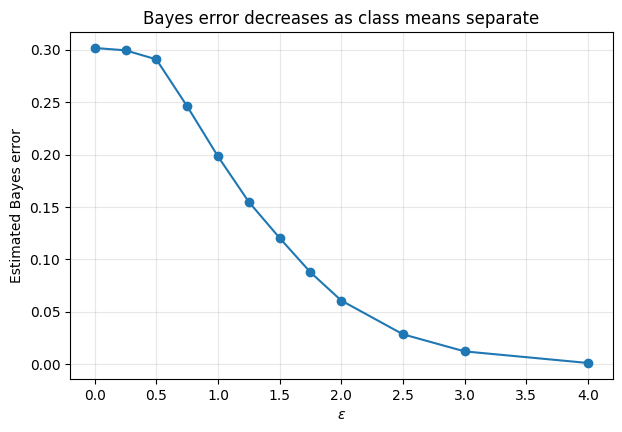

In [2]:
class GaussianBayesClassifier(BaseEstimator, ClassifierMixin):
    """Bayes classifier for the TP3 two-class Gaussian model."""

    def __init__(self, epsilon=2.0, p=0.3):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X=None, y=None):
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = 2
        return self

    def decision_function(self, X):
        X = np.asarray(X)
        x1 = X[:, 0]
        x2 = X[:, 1]
        return (
            np.log(self.p / (1 - self.p))
            + np.log(1.25)
            - 0.25 * (x1**2 + x2**2)
            + 2.5 * self.epsilon * x1
            - 1.25 * self.epsilon**2
        )

    def predict_proba(self, X):
        logits = self.decision_function(X)
        proba_1 = 1 / (1 + np.exp(-logits))
        return np.column_stack([1 - proba_1, proba_1])

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)


bayes = GaussianBayesClassifier(epsilon=2.0, p=0.3).fit()
X_bayes, y_bayes = simulate_data(10_000, epsilon=2.0, p=0.3, rng=rng)
bayes_error = zero_one_loss(y_bayes, bayes.predict(X_bayes))
print(f"Estimated Bayes error for D(10^4 | 2, 0.3): {bayes_error:.4f}")

epsilon_grid = np.array([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 4.0])
bayes_errors = []

for epsilon in epsilon_grid:
    X_eps, y_eps = simulate_data(50_000, epsilon=epsilon, p=0.3, rng=rng)
    clf = GaussianBayesClassifier(epsilon=epsilon, p=0.3).fit()
    bayes_errors.append(zero_one_loss(y_eps, clf.predict(X_eps)))

bayes_error_table = pd.DataFrame({"epsilon": epsilon_grid, "estimated Bayes error": bayes_errors})
display(bayes_error_table)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epsilon_grid, bayes_errors, marker="o")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel("Estimated Bayes error")
ax.set_title("Bayes error decreases as class means separate")
ax.grid(alpha=0.3)
plt.show()


**Interpretation.** The Bayes error is about `0.06` for $\varepsilon=2$ and $p=0.3$ in this simulation. As $\varepsilon$ increases, the class means move farther apart, the overlap between the Gaussian clouds decreases, and the Bayes error goes down. When $\varepsilon$ is close to zero, the classes are difficult to separate because their means are almost identical; the classifier can then exploit mostly the prior and the small covariance difference.


**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**Answer.** The most adequate classifier from the lecture is **QDA**.

The reason is that the data-generating model is Gaussian conditional on the class, but the two covariance matrices are different:

$$
\Sigma_0 = 0.5I, \qquad \Sigma_1 = 0.4I.
$$

LDA assumes Gaussian class-conditional distributions with a common covariance matrix. QDA assumes Gaussian class-conditional distributions with class-specific covariance matrices. Therefore QDA is the model whose assumptions match the simulation.

Logistic regression can still work well here, but it learns a linear decision boundary. The exact Bayes boundary is quadratic, so logistic regression is misspecified for this generative model.


**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

,classifier,test error
0,Bayes,0.068
1,LDA,0.072
2,QDA,0.067
3,Logistic regression,0.077


,training size,LDA mean error,LDA std,QDA mean error,QDA std,Logistic regression mean error,Logistic regression std
0,20,0.080649,0.021385,0.104494,0.055285,0.096403,0.039761
1,50,0.068318,0.006959,0.073147,0.012710,0.072641,0.010877
2,100,0.064736,0.003777,0.065038,0.004180,0.065885,0.005428
3,200,0.063073,0.001719,0.063198,0.002087,0.063752,0.002514
4,500,0.062175,0.001028,0.061797,0.000800,0.062347,0.001178
5,1000,0.061811,0.000832,0.061315,0.000626,0.061632,0.000628
6,5000,0.061485,0.000414,0.060821,0.000272,0.061083,0.000224


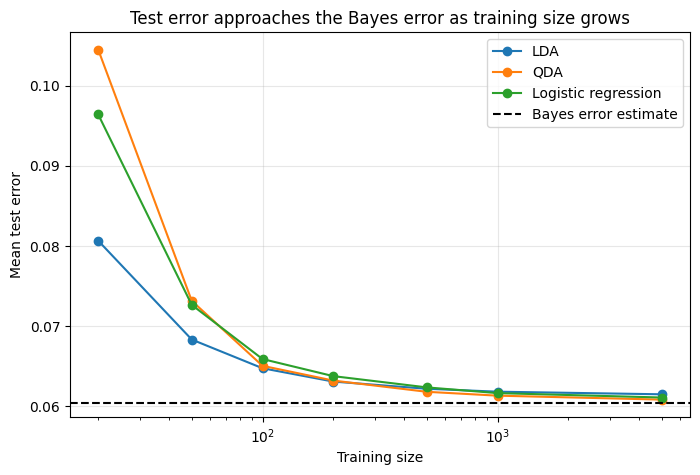

In [3]:
models = {
    "Bayes": GaussianBayesClassifier(epsilon=2.0, p=0.3).fit(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000)),
}

rows = []
for name, model in models.items():
    if name != "Bayes":
        model.fit(X_train, y_train)
    test_error = zero_one_loss(y_test, model.predict(X_test))
    rows.append({"classifier": name, "test error": test_error})

error_table = pd.DataFrame(rows)
display(error_table)

# Empirical study of the effect of training size.
X_eval, y_eval = simulate_data(20_000, epsilon=2.0, p=0.3, rng=rng)
train_sizes = [20, 50, 100, 200, 500, 1_000, 5_000]
n_repetitions = 80
size_rows = []

for n_train in train_sizes:
    errors = {"LDA": [], "QDA": [], "Logistic regression": []}
    while len(errors["LDA"]) < n_repetitions:
        X_tmp, y_tmp = simulate_data(n_train, epsilon=2.0, p=0.3, rng=rng)
        if np.bincount(y_tmp, minlength=2).min() < 3:
            continue

        classifiers = {
            "LDA": LinearDiscriminantAnalysis(),
            "QDA": QuadraticDiscriminantAnalysis(),
            "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000)),
        }
        for name, clf in classifiers.items():
            clf.fit(X_tmp, y_tmp)
            errors[name].append(zero_one_loss(y_eval, clf.predict(X_eval)))

    row = {"training size": n_train}
    for name, vals in errors.items():
        row[f"{name} mean error"] = np.mean(vals)
        row[f"{name} std"] = np.std(vals)
    size_rows.append(row)

size_effect_table = pd.DataFrame(size_rows)
display(size_effect_table)

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["LDA", "QDA", "Logistic regression"]:
    ax.plot(
        size_effect_table["training size"],
        size_effect_table[f"{name} mean error"],
        marker="o",
        label=name,
    )
ax.axhline(bayes_error, color="black", linestyle="--", label="Bayes error estimate")
ax.set_xscale("log")
ax.set_xlabel("Training size")
ax.set_ylabel("Mean test error")
ax.set_title("Test error approaches the Bayes error as training size grows")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


**Interpretation.** In the fixed simulation, QDA is typically closest to the Bayes classifier because it is correctly specified. LDA and logistic regression are often close because $0.5I$ and $0.4I$ are similar covariance matrices, so the true quadratic boundary is not very far from a linear one in the dense part of the data.

When the training size increases, the gap between each fitted classifier and its population target decreases because parameter estimation becomes more accurate. QDA should converge to the Bayes classifier because its assumptions match the data-generating process. LDA and logistic regression converge to their best linear approximations; any remaining gap is due to model misspecification.


**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [4]:
X_shift, y_shift = simulate_data(1_000, epsilon=0.5, p=0.7, rng=rng)

shift_rows = []
for name, model in models.items():
    shift_error = zero_one_loss(y_shift, model.predict(X_shift))
    shift_rows.append({"classifier trained on D_train": name, "shifted test error": shift_error})

oracle_shift = GaussianBayesClassifier(epsilon=0.5, p=0.7).fit()
shift_rows.append({
    "classifier trained on D_train": "Oracle Bayes for shifted distribution",
    "shifted test error": zero_one_loss(y_shift, oracle_shift.predict(X_shift)),
})

shift_table = pd.DataFrame(shift_rows)
display(shift_table)

print(f"Shifted test class counts: {np.bincount(y_shift, minlength=2)}")


,classifier trained on D_train,shifted test error
0,Bayes,0.616
1,LDA,0.615
2,QDA,0.603
3,Logistic regression,0.634
4,Oracle Bayes for shifted distribution,0.272


Shifted test class counts: [303 697]


**Interpretation.** All classifiers trained on the original distribution perform much worse on $D'_{test}$. This is not mainly an implementation problem; it is a distribution-shift problem.

The training data were generated with $\varepsilon=2$ and $p=0.3$, while the new test data are generated with $\varepsilon=0.5$ and $p=0.7$. Both the class prior and the class separation changed. Therefore the posterior probabilities learned from the training distribution are no longer the right posterior probabilities for the test distribution.

Possible fixes are to collect representative training data from the new distribution, retrain the classifier, recalibrate the decision threshold if only the prior has changed, or use domain-adaptation methods when labeled data from the new distribution are scarce.


## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [5]:
def download_titanic_data():
    """Download the Kaggle Titanic competition files with kagglehub when available."""
    try:
        import warnings
        warnings.filterwarnings("ignore", message="IProgress not found.*")
        import kagglehub
    except ModuleNotFoundError:
        print("kagglehub is not installed in this environment.")
        print("Install it with: pip install kagglehub")
        return None

    try:
        path = Path(kagglehub.competition_download("titanic"))
        print("Path to competition files:", path)
        return path
    except Exception as exc:
        print("kagglehub could not download the Titanic files.")
        print(f"Reason: {exc}")
        print("If authentication is missing, run kagglehub.login() once with your Kaggle API token, then rerun this cell.")
        return None


def find_titanic_file(filename, downloaded_dir=None):
    if downloaded_dir is not None:
        direct_path = downloaded_dir / filename
        if direct_path.exists():
            return direct_path
        matches = list(downloaded_dir.rglob(filename))
        if matches:
            return matches[0]

    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("titanic") / filename,
        Path("TP") / "TP3" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def add_titanic_features(df):
    df = df.copy()
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).fillna("Unknown")
    common_titles = {"Mr", "Mrs", "Miss", "Master"}
    df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["Deck"] = df["Cabin"].str[0].fillna("Unknown")
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"].replace(0, np.nan)
    return df


downloaded_titanic_dir = None
train_path = find_titanic_file("train.csv")
test_path = find_titanic_file("test.csv")

if train_path is None or test_path is None:
    downloaded_titanic_dir = download_titanic_data()
    train_path = find_titanic_file("train.csv", downloaded_titanic_dir)
    test_path = find_titanic_file("test.csv", downloaded_titanic_dir)

if train_path is None or test_path is None:
    print("Titanic CSV files were not found locally.")
    print("Download train.csv and test.csv from Kaggle, then place them next to this notebook or in a data/ folder.")
else:
    titanic_train = pd.read_csv(train_path)
    titanic_test = pd.read_csv(test_path)

    train_fe = add_titanic_features(titanic_train)
    test_fe = add_titanic_features(titanic_test)

    feature_columns = [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked",
        "Title",
        "FamilySize",
        "IsAlone",
        "Deck",
        "FarePerPerson",
    ]
    numerical_features = ["Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "FarePerPerson"]
    categorical_features = ["Pclass", "Sex", "Embarked", "Title", "Deck"]

    X_titanic = train_fe[feature_columns]
    y_titanic = train_fe["Survived"]

    print(f"Training shape: {X_titanic.shape}")
    print(f"Test shape:     {test_fe[feature_columns].shape}")
    display(train_fe[feature_columns + ["Survived"]].head())


Training shape: (891, 12)
Test shape:     (418, 12)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,Deck,FarePerPerson,Survived
0,3,male,22.0,1,0,7.2500,S,Mr,2,0,Unknown,3.62500,0
1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,C,35.64165,1
2,3,female,26.0,0,0,7.9250,S,Miss,1,1,Unknown,7.92500,1
3,1,female,35.0,1,0,53.1000,S,Mrs,2,0,C,26.55000,1
4,3,male,35.0,0,0,8.0500,S,Mr,1,1,Unknown,8.05000,0


**Answer.** The notebook first looks for `train.csv` and `test.csv` next to the notebook or in a local `titanic/` or `data/` folder. If the files are missing, it tries to download them with:

```python
import kagglehub
path = kagglehub.competition_download("titanic")
```

The feature engineering keeps the main raw predictors and adds simple domain features:

- `Title` is extracted from `Name` and rare titles are grouped together;
- `FamilySize = SibSp + Parch + 1` measures the size of the passenger's family group on board;
- `IsAlone` indicates passengers traveling without recorded family;
- `Deck` is extracted from the first letter of `Cabin`, with missing cabins encoded as `Unknown`;
- `FarePerPerson = Fare / FamilySize` reduces the effect of family tickets sharing one fare.

Numerical variables are median-imputed and standardized. Categorical variables are imputed and one-hot encoded with `handle_unknown="ignore"` so that categories appearing only in the Kaggle test set do not crash prediction.

The key methodological point is that imputation and encoding are inside a scikit-learn `Pipeline` and `ColumnTransformer`; otherwise cross-validation would leak information from the validation folds into preprocessing.


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

In [6]:
if train_path is None or test_path is None:
    print("No local Titanic data: the model and submission file cannot be produced yet.")
else:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    titanic_model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("classifier", LogisticRegression(max_iter=2_000)),
        ]
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_scores = cross_val_score(titanic_model, X_titanic, y_titanic, cv=cv, scoring="accuracy")
    print(f"5-fold stratified CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

    titanic_model.fit(X_titanic, y_titanic)
    test_predictions = titanic_model.predict(test_fe[feature_columns])

    submission = pd.DataFrame({
        "PassengerId": titanic_test["PassengerId"],
        "Survived": test_predictions.astype(int),
    })
    submission_path = Path("titanic_submission.csv")
    submission.to_csv(submission_path, index=False)
    display(submission.head())
    print(f"Submission written to {submission_path.resolve()}")


5-fold stratified CV accuracy: 0.8250 +/- 0.0251


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Submission written to /home/pmarrec/vault/Projects/Enseignement/2026-main/TP/TP3/titanic_submission.csv


**Answer.** I used logistic regression with a full preprocessing pipeline. This is a simple, interpretable, and strong baseline for this small mixed-type tabular dataset. The local 5-fold stratified cross-validation accuracy is about `0.825 +/- 0.025` in the executed notebook.

The notebook writes `titanic_submission.csv`. The remaining missing value is the **public Kaggle leaderboard score**, which can only be obtained after uploading that CSV to the Titanic competition page. After submission, paste the public score here.
